# Embedding-Based Node Repair (Overfit First Pass)

This notebook implements a first-pass repair experiment where:
1. The trained GNN is frozen.
2. Only initially incorrect nodes are trainable in input space.
3. We overfit strongly to labels.
4. We measure how much repaired features moved from original features.

## Term Definitions

All analysis terms are defined in:
- src/notebooks/graph_embed_repair_terms.md

Key terms used here: target nodes, entropy, embedding table, frozen model, fixed/regressed, L2 drift, cosine distance.

In [1]:
import os
import sys
import copy
import random

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Make src importable from notebook location.
sys.path.append(os.path.abspath('..'))

from loading.LightningGraphLoader import load_datasets
from models.MyModel import MyModel

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

def split_acc(pred, y, train_mask, val_mask, test_mask):
    corr = (pred == y)
    out = {
        'overall': corr.float().mean().item(),
        'train': corr[train_mask].float().mean().item(),
        'val': corr[val_mask].float().mean().item(),
        'test': corr[test_mask].float().mean().item(),
    }
    return out, corr

/Users/williserdman/Documents/school/spring2026/db4ai/db4ai/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# If needed, run from repo root.
os.chdir('../..')
print('cwd:', os.getcwd())

# ---- Experiment config ----
ds_name = 'ENGB'
checkpoint_path = 'optuna_logs/best_params/version_2/checkpoints/epoch=529-step=530.ckpt'

# Overfit controls
MAX_EPOCHS = 500
LR = 0.1
WEIGHT_DECAY = 0.0
LOG_EVERY = 25

# Keep this None to use all initially incorrect nodes.
# Set an integer for quick smoke tests on large graphs.
MAX_TARGET_NODES = None

# Optional regularization to keep repaired features close to original features.
L2_TO_ORIGINAL = 0.0

# Optional entropy weighting for target-node loss.
USE_ENTROPY_WEIGHTING = False

cwd: /Users/williserdman/Documents/school/spring2026/db4ai/db4ai


In [3]:
# ---- Load data and frozen model ----
data_dict = load_datasets([ds_name])
lightning_data = data_dict[ds_name]
dl = lightning_data.data.train_dataloader()
graph_data = dl.dataset[0]

model = MyModel.load_from_checkpoint(checkpoint_path)
model.eval()

device = next(model.parameters()).device
for p in model.parameters():
    p.requires_grad = False

graph_data = graph_data.to(device)

x_original = graph_data.x.detach().clone()
y = graph_data.y
train_mask = graph_data.train_mask
val_mask = graph_data.val_mask
test_mask = graph_data.test_mask

num_nodes, num_features = x_original.shape
num_classes = int(y.max().item()) + 1
print(f'dataset={ds_name} nodes={num_nodes} features={num_features} classes={num_classes}')
print('device:', device)

Data(x=[7126, 3170], edge_index=[2, 35324], y=[7126], train_mask=[7126], val_mask=[7126], test_mask=[7126])


/Users/williserdman/Documents/school/spring2026/db4ai/db4ai/.venv/lib/python3.13/site-packages/torch_geometric/io/fs.py:229: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([torch_geometric.data.data.DataEdgeAttr])` to allowlist this global.
  warnings.warn(f"{warn_msg} Please use "
/Users/williserdman/Documents/school/spring2026/db4ai/db4ai/.venv/lib/python3.13/site-packages/torch_geometric/data/in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)
/Users/williserdman/Documents/school/spring2026/db4ai/db4ai/src/loading

dataset=ENGB nodes=7126 features=3170 classes=2
device: cpu


/Users/williserdman/Documents/school/spring2026/db4ai/db4ai/src/models/MyModel.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.cse = nn.CrossEntropyLoss(torch.tensor(ds_info.class_weights))


In [4]:
# ---- Baseline forward pass ----
with torch.no_grad():
    logits_base, _ = model(graph_data)
    probs_base = torch.softmax(logits_base, dim=1)
    pred_base = logits_base.argmax(dim=1)

metrics_base, correct_base = split_acc(pred_base, y, train_mask, val_mask, test_mask)
incorrect_mask = ~correct_base

eps = 1e-12
entropy = -(probs_base.clamp_min(eps) * probs_base.clamp_min(eps).log()).sum(dim=1)
confidence = probs_base.max(dim=1).values

print('Baseline metrics:')
for k, v in metrics_base.items():
    print(f'  {k}: {v:.4f}')
print('Initially incorrect nodes:', int(incorrect_mask.sum().item()))

Baseline metrics:
  overall: 0.7241
  train: 0.7305
  val: 0.7200
  test: 0.7090
Initially incorrect nodes: 1966


In [5]:
# ---- Define trainable target set (initially incorrect only) ----
target_mask = incorrect_mask.clone()
target_indices = torch.where(target_mask)[0]

if MAX_TARGET_NODES is not None and target_indices.numel() > MAX_TARGET_NODES:
    # Keep highest-entropy incorrect nodes when capping targets.
    order = torch.argsort(entropy[target_indices], descending=True)
    target_indices = target_indices[order[:MAX_TARGET_NODES]]
    target_mask = torch.zeros_like(target_mask, dtype=torch.bool)
    target_mask[target_indices] = True

if target_indices.numel() == 0:
    raise RuntimeError('No target nodes selected for repair.')

non_target_mask = ~target_mask
target_mask_f = target_mask.float().unsqueeze(1)

print('Target nodes selected:', int(target_indices.numel()))
print('Non-target nodes:', int(non_target_mask.sum().item()))

Target nodes selected: 1966
Non-target nodes: 5160


In [6]:
""" # ---- Trainable embedding delta (same shape as X) ----
# x_repaired = x_original + target_mask * delta_param
delta_param = torch.nn.Parameter(torch.zeros_like(x_original))
optimizer = torch.optim.Adam([delta_param], lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

history = {
    'epoch': [],
    'loss_total': [],
    'loss_target_ce': [],
    'loss_l2': [],
    'overall': [],
    'train': [],
    'val': [],
    'test': [],
    'fixed': [],
    'regressed': [],
    'net': [],
    'target_grad_mean': [],
    'target_grad_max': [],
    'zero_grad_target_rows': [],
    'target_delta_l2_mean': [],
    'target_delta_l2_max': [],
}

best_val = -1.0
best_state = None

for epoch in range(1, MAX_EPOCHS + 1):
    optimizer.zero_grad()

    delta_masked = delta_param * target_mask_f
    x_repaired = x_original + delta_masked

    data_tmp = graph_data.clone()
    data_tmp.x = x_repaired

    logits, _ = model(data_tmp)

    logits_target = logits[target_mask]
    y_target = y[target_mask]

    if USE_ENTROPY_WEIGHTING:
        weights = entropy[target_mask].detach()
        weights = weights / (weights.mean() + 1e-12)
        per_node_ce = F.cross_entropy(logits_target, y_target, reduction='none')
        loss_target_ce = (weights * per_node_ce).mean()
    else:
        loss_target_ce = F.cross_entropy(logits_target, y_target)

    if L2_TO_ORIGINAL > 0.0:
        loss_l2 = (delta_masked[target_mask]).pow(2).mean()
    else:
        loss_l2 = torch.tensor(0.0, device=device)

    loss_total = loss_target_ce + (L2_TO_ORIGINAL * loss_l2)
    loss_total.backward()

    # Gradient diagnostics for target rows only.
    with torch.no_grad():
        grad = delta_param.grad
        target_grad = grad[target_mask]
        target_grad_norm = target_grad.norm(dim=1)
        zero_grad_rows = (target_grad_norm < 1e-12).sum().item()

    optimizer.step()
    scheduler.step()

    if epoch % LOG_EVERY == 0 or epoch == 1 or epoch == MAX_EPOCHS:
        with torch.no_grad():
            pred_now = logits.argmax(dim=1)
            m_now, corr_now = split_acc(pred_now, y, train_mask, val_mask, test_mask)

            fixed = ((~correct_base) & corr_now).sum().item()
            regressed = (correct_base & (~corr_now)).sum().item()
            net = fixed - regressed

            delta_now = (delta_param * target_mask_f)[target_mask]
            delta_l2 = delta_now.norm(dim=1)

            history['epoch'].append(epoch)
            history['loss_total'].append(loss_total.item())
            history['loss_target_ce'].append(loss_target_ce.item())
            history['loss_l2'].append(loss_l2.item())
            history['overall'].append(m_now['overall'])
            history['train'].append(m_now['train'])
            history['val'].append(m_now['val'])
            history['test'].append(m_now['test'])
            history['fixed'].append(fixed)
            history['regressed'].append(regressed)
            history['net'].append(net)
            history['target_grad_mean'].append(target_grad_norm.mean().item())
            history['target_grad_max'].append(target_grad_norm.max().item())
            history['zero_grad_target_rows'].append(int(zero_grad_rows))
            history['target_delta_l2_mean'].append(delta_l2.mean().item())
            history['target_delta_l2_max'].append(delta_l2.max().item())

            if m_now['val'] > best_val:
                best_val = m_now['val']
                best_state = {
                    'epoch': epoch,
                    'delta': delta_param.detach().clone(),
                    'pred': pred_now.detach().clone(),
                    'metrics': m_now,
                }

            print(
                f"epoch={epoch:4d} loss={loss_total.item():.4f} ce={loss_target_ce.item():.4f} "
                f"overall={m_now['overall']:.4f} val={m_now['val']:.4f} test={m_now['test']:.4f} "
                f"fixed={fixed} reg={regressed} net={net:+d}"
            )

print('Optimization complete.')
print('Best val epoch:', best_state['epoch'] if best_state is not None else None) """

' # ---- Trainable embedding delta (same shape as X) ----\n# x_repaired = x_original + target_mask * delta_param\ndelta_param = torch.nn.Parameter(torch.zeros_like(x_original))\noptimizer = torch.optim.Adam([delta_param], lr=LR, weight_decay=WEIGHT_DECAY)\nscheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)\n\nhistory = {\n    \'epoch\': [],\n    \'loss_total\': [],\n    \'loss_target_ce\': [],\n    \'loss_l2\': [],\n    \'overall\': [],\n    \'train\': [],\n    \'val\': [],\n    \'test\': [],\n    \'fixed\': [],\n    \'regressed\': [],\n    \'net\': [],\n    \'target_grad_mean\': [],\n    \'target_grad_max\': [],\n    \'zero_grad_target_rows\': [],\n    \'target_delta_l2_mean\': [],\n    \'target_delta_l2_max\': [],\n}\n\nbest_val = -1.0\nbest_state = None\n\nfor epoch in range(1, MAX_EPOCHS + 1):\n    optimizer.zero_grad()\n\n    delta_masked = delta_param * target_mask_f\n    x_repaired = x_original + delta_masked\n\n    data_tmp = graph_data.clone()\

In [7]:
# ---- Alternative run: train on all nodes (no val/test gating) ----
MAX_EPOCHS_ALL = 500
LR_ALL = 0.1
WEIGHT_DECAY_ALL = 0.0
LOG_EVERY_ALL = 25

# Optional regularization to keep updates bounded in overfit mode.
L2_TO_ORIGINAL_ALL = 0.0

delta_param_all = torch.nn.Parameter(torch.zeros_like(x_original))
optimizer_all = torch.optim.Adam([delta_param_all], lr=LR_ALL, weight_decay=WEIGHT_DECAY_ALL)
scheduler_all = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_all, T_max=MAX_EPOCHS_ALL)

history_all = {
    'epoch': [],
    'loss_total': [],
    'loss_all_ce': [],
    'loss_l2': [],
    'overall': [],
    'fixed': [],
    'regressed': [],
    'net': [],
}

best_overall_all = -1.0
best_state_all = None

for epoch in range(1, MAX_EPOCHS_ALL + 1):
    optimizer_all.zero_grad()

    delta_masked_all = delta_param_all * target_mask_f
    x_repaired_all = x_original + delta_masked_all

    data_tmp_all = graph_data.clone()
    data_tmp_all.x = x_repaired_all

    logits_all, _ = model(data_tmp_all)
    pred_all = logits_all.argmax(dim=1)

    # Train on every node label directly.
    loss_all_ce = F.cross_entropy(logits_all, y)

    if L2_TO_ORIGINAL_ALL > 0.0:
        loss_l2_all = (delta_masked_all[target_mask]).pow(2).mean()
    else:
        loss_l2_all = torch.tensor(0.0, device=device)

    loss_total_all = loss_all_ce + (L2_TO_ORIGINAL_ALL * loss_l2_all)
    loss_total_all.backward()

    optimizer_all.step()
    scheduler_all.step()

    if epoch % LOG_EVERY_ALL == 0 or epoch == 1 or epoch == MAX_EPOCHS_ALL:
        with torch.no_grad():
            metrics_now_all, corr_now_all = split_acc(pred_all, y, train_mask, val_mask, test_mask)
            fixed_all = ((~correct_base) & corr_now_all).sum().item()
            regressed_all = (correct_base & (~corr_now_all)).sum().item()
            net_all = fixed_all - regressed_all

            history_all['epoch'].append(epoch)
            history_all['loss_total'].append(loss_total_all.item())
            history_all['loss_all_ce'].append(loss_all_ce.item())
            history_all['loss_l2'].append(loss_l2_all.item())
            history_all['overall'].append(metrics_now_all['overall'])
            history_all['fixed'].append(fixed_all)
            history_all['regressed'].append(regressed_all)
            history_all['net'].append(net_all)

            if metrics_now_all['overall'] > best_overall_all:
                best_overall_all = metrics_now_all['overall']
                best_state_all = {
                    'epoch': epoch,
                    'delta': delta_param_all.detach().clone(),
                    'pred': pred_all.detach().clone(),
                    'metrics': metrics_now_all,
                }

            print(
                f"[all-node] epoch={epoch:4d} loss={loss_total_all.item():.4f} ce={loss_all_ce.item():.4f} "
                f"overall={metrics_now_all['overall']:.4f} fixed={fixed_all} reg={regressed_all} net={net_all:+d}"
            )

print('All-node training complete.')
print('Best overall epoch:', best_state_all['epoch'] if best_state_all is not None else None)

[all-node] epoch=   1 loss=0.6232 ce=0.6232 overall=0.7241 fixed=0 reg=0 net=+0
[all-node] epoch=  25 loss=220.6705 ce=220.6705 overall=0.7358 fixed=1680 reg=1597 net=+83
[all-node] epoch=  50 loss=153.3512 ce=153.3512 overall=0.7610 fixed=1804 reg=1541 net=+263
[all-node] epoch=  75 loss=103.5471 ce=103.5471 overall=0.7752 fixed=1856 reg=1492 net=+364
[all-node] epoch= 100 loss=77.8930 ce=77.8930 overall=0.8065 fixed=1896 reg=1309 net=+587
[all-node] epoch= 125 loss=62.3202 ce=62.3202 overall=0.8134 fixed=1905 reg=1269 net=+636
[all-node] epoch= 150 loss=52.8825 ce=52.8825 overall=0.8134 fixed=1919 reg=1283 net=+636
[all-node] epoch= 175 loss=42.9467 ce=42.9467 overall=0.8254 fixed=1935 reg=1213 net=+722
[all-node] epoch= 200 loss=34.3596 ce=34.3596 overall=0.8385 fixed=1943 reg=1128 net=+815
[all-node] epoch= 225 loss=26.2985 ce=26.2985 overall=0.8470 fixed=1948 reg=1072 net=+876
[all-node] epoch= 250 loss=23.7073 ce=23.7073 overall=0.8569 fixed=1954 reg=1008 net=+946
[all-node] epoc

In [10]:
best_state = best_state_all
history = history_all

In [14]:

# ---- Final evaluation and drift analysis ----
if best_state is None:
    raise RuntimeError('No best state recorded.')

delta_best = best_state['delta'] * target_mask_f
x_repaired_best = x_original + delta_best

data_best = graph_data.clone()
data_best.x = x_repaired_best

with torch.no_grad():
    logits_best, _ = model(data_best)
    pred_best = logits_best.argmax(dim=1)

metrics_best, correct_best = split_acc(pred_best, y, train_mask, val_mask, test_mask)

fixed_mask = (~correct_base) & correct_best
regressed_mask = correct_base & (~correct_best)
still_wrong_mask = (~correct_base) & (~correct_best)
always_correct_mask = correct_base & correct_best

drift = (x_repaired_best - x_original)
drift_l2 = drift.norm(dim=1)
cos_sim = F.cosine_similarity(x_repaired_best, x_original, dim=1, eps=1e-12)
drift_cosine = 1.0 - cos_sim

def summarize_group(mask, name):
    if mask.sum() == 0:
        return {
            'group': name,
            'count': 0,
            'l2_mean': float('nan'),
            'l2_median': float('nan'),
            'cos_mean': float('nan'),
            'cos_median': float('nan'),
        }
    return {
        'group': name,
        'count': int(mask.sum().item()),
        'l2_mean': float(drift_l2[mask].mean().item()),
        'l2_median': float(drift_l2[mask].median().item()),
        'cos_mean': float(drift_cosine[mask].mean().item()),
        'cos_median': float(drift_cosine[mask].median().item()),
    }

rows = [
    summarize_group(fixed_mask, 'fixed'),
    summarize_group(still_wrong_mask, 'still_wrong'),
    summarize_group(regressed_mask, 'regressed'),
    summarize_group(always_correct_mask, 'always_correct'),
]

print('Baseline metrics:', metrics_base)
print('Best metrics    :', metrics_best)
print('Counts: fixed={}, regressed={}, net={:+d}'.format(
    int(fixed_mask.sum().item()),
    int(regressed_mask.sum().item()),
    int(fixed_mask.sum().item() - regressed_mask.sum().item()),
))

print('\nDrift summary by outcome group:')
for r in rows:
    print(r)

# Isolation check: non-target rows should remain unchanged (or tiny numerical noise).
non_target_l2_max = drift_l2[non_target_mask].max().item() if non_target_mask.any() else 0.0
print('\nNon-target max L2 drift:', non_target_l2_max)

Baseline metrics: {'overall': 0.724108874797821, 'train': 0.730526328086853, 'val': 0.7200000286102295, 'test': 0.708976149559021}
Best metrics    : {'overall': 0.8978388905525208, 'train': 0.9015204906463623, 'val': 0.8933333158493042, 'test': 0.8913043737411499}
Counts: fixed=1959, regressed=721, net=+1238

Drift summary by outcome group:
{'group': 'fixed', 'count': 1959, 'l2_mean': 52.90570068359375, 'l2_median': 44.428409576416016, 'cos_mean': 0.9926397204399109, 'cos_median': 0.9930060505867004}
{'group': 'still_wrong', 'count': 7, 'l2_mean': 56.23974609375, 'l2_median': 54.53765106201172, 'cos_mean': 0.9752878546714783, 'cos_median': 0.9741089940071106}
{'group': 'regressed', 'count': 721, 'l2_mean': 0.0, 'l2_median': 0.0, 'cos_mean': 2.2816756484189682e-08, 'cos_median': 0.0}
{'group': 'always_correct', 'count': 4439, 'l2_mean': 0.0, 'l2_median': 0.0, 'cos_mean': 2.1134875183292934e-08, 'cos_median': 0.0}

Non-target max L2 drift: 0.0


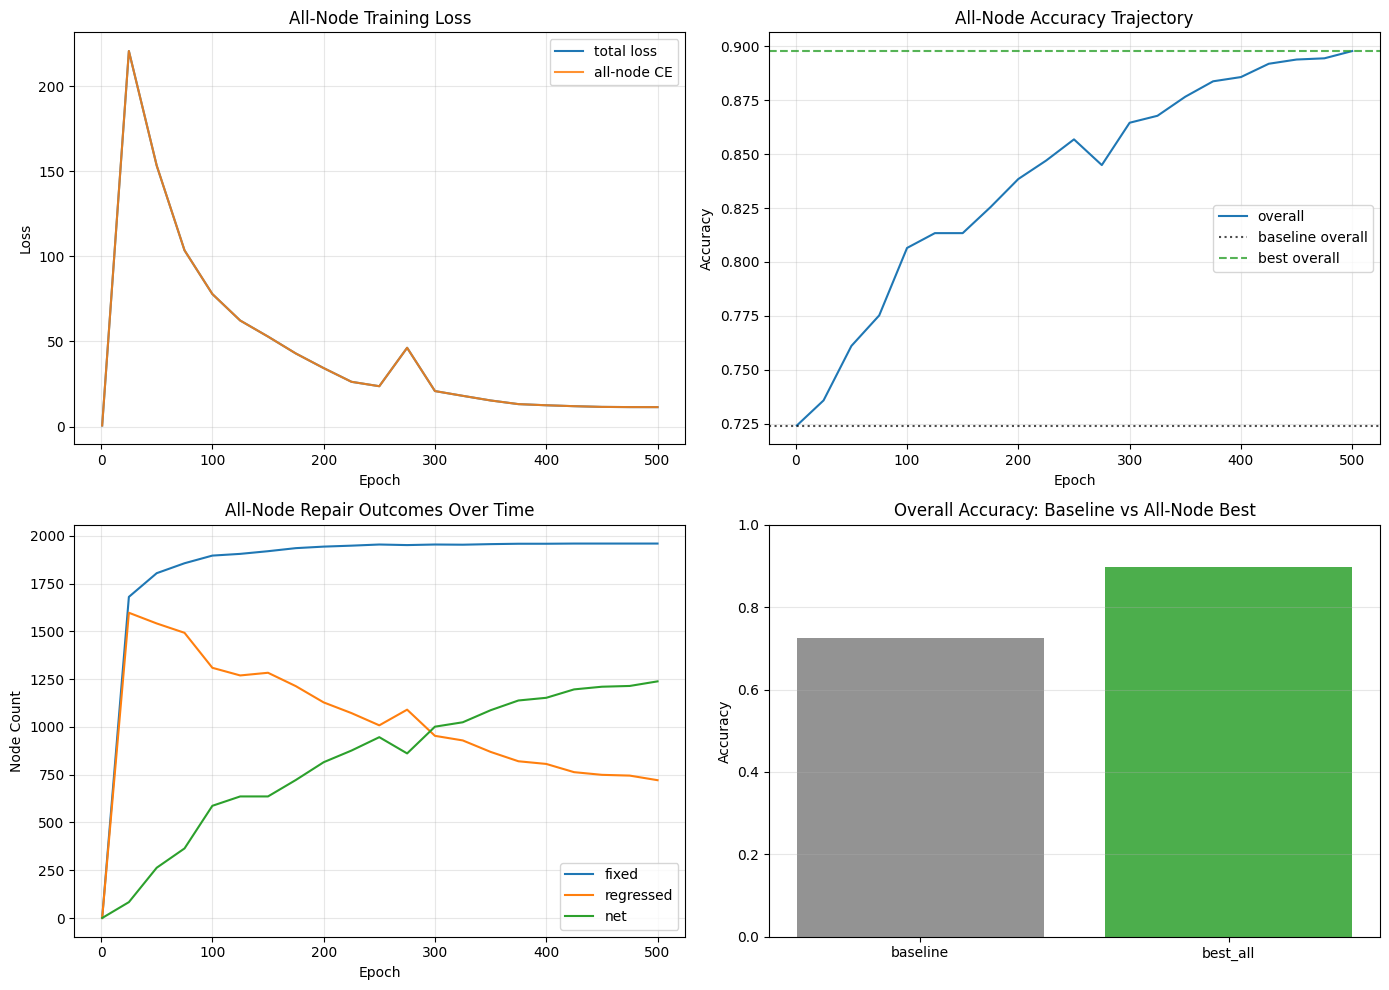

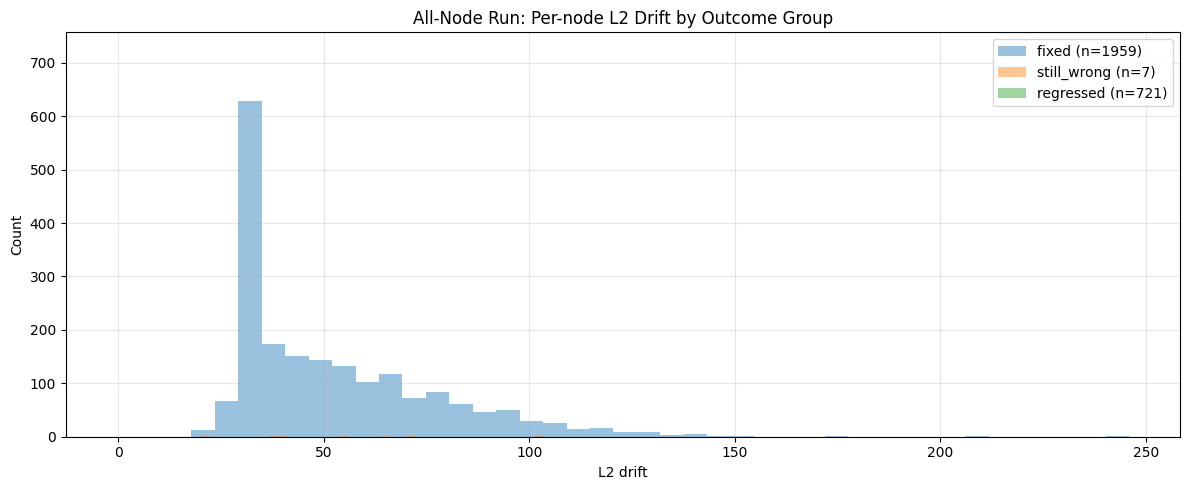

In [15]:
# ---- Graphics: all-node training run ----
epochs_all = history_all['epoch']

fig, axes_all = plt.subplots(2, 2, figsize=(14, 10))

# (1) Loss trajectory
axes_all[0, 0].plot(epochs_all, history_all['loss_total'], label='total loss')
axes_all[0, 0].plot(epochs_all, history_all['loss_all_ce'], label='all-node CE', alpha=0.85)
axes_all[0, 0].set_title('All-Node Training Loss')
axes_all[0, 0].set_xlabel('Epoch')
axes_all[0, 0].set_ylabel('Loss')
axes_all[0, 0].grid(alpha=0.3)
axes_all[0, 0].legend()

# (2) Accuracy trajectory (overall only logged in history_all)
axes_all[0, 1].plot(epochs_all, history_all['overall'], label='overall')
axes_all[0, 1].axhline(metrics_base['overall'], linestyle=':', color='k', alpha=0.7, label='baseline overall')
axes_all[0, 1].axhline(best_state_all['metrics']['overall'], linestyle='--', color='tab:green', alpha=0.8, label='best overall')
axes_all[0, 1].set_title('All-Node Accuracy Trajectory')
axes_all[0, 1].set_xlabel('Epoch')
axes_all[0, 1].set_ylabel('Accuracy')
axes_all[0, 1].grid(alpha=0.3)
axes_all[0, 1].legend()

# (3) Fixed / regressed / net
axes_all[1, 0].plot(epochs_all, history_all['fixed'], label='fixed')
axes_all[1, 0].plot(epochs_all, history_all['regressed'], label='regressed')
axes_all[1, 0].plot(epochs_all, history_all['net'], label='net')
axes_all[1, 0].set_title('All-Node Repair Outcomes Over Time')
axes_all[1, 0].set_xlabel('Epoch')
axes_all[1, 0].set_ylabel('Node Count')
axes_all[1, 0].grid(alpha=0.3)
axes_all[1, 0].legend()

# (4) End-of-run summary bars
summary_labels = ['baseline', 'best_all']
summary_vals = [metrics_base['overall'], best_state_all['metrics']['overall']]
axes_all[1, 1].bar(summary_labels, summary_vals, color=['gray', 'tab:green'], alpha=0.85)
axes_all[1, 1].set_ylim(0, 1.0)
axes_all[1, 1].set_title('Overall Accuracy: Baseline vs All-Node Best')
axes_all[1, 1].set_ylabel('Accuracy')
axes_all[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Drift distributions by final outcome group (from best all-node state)
plot_groups_all = [
    ('fixed', fixed_mask),
    ('still_wrong', still_wrong_mask),
    ('regressed', regressed_mask),
]

plt.figure(figsize=(12, 5))
for name, mask in plot_groups_all:
    if mask.sum() > 0:
        plt.hist(drift_l2[mask].detach().cpu().numpy(), bins=40, alpha=0.45, label=f'{name} (n={int(mask.sum())})')
plt.title('All-Node Run: Per-node L2 Drift by Outcome Group')
plt.xlabel('L2 drift')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

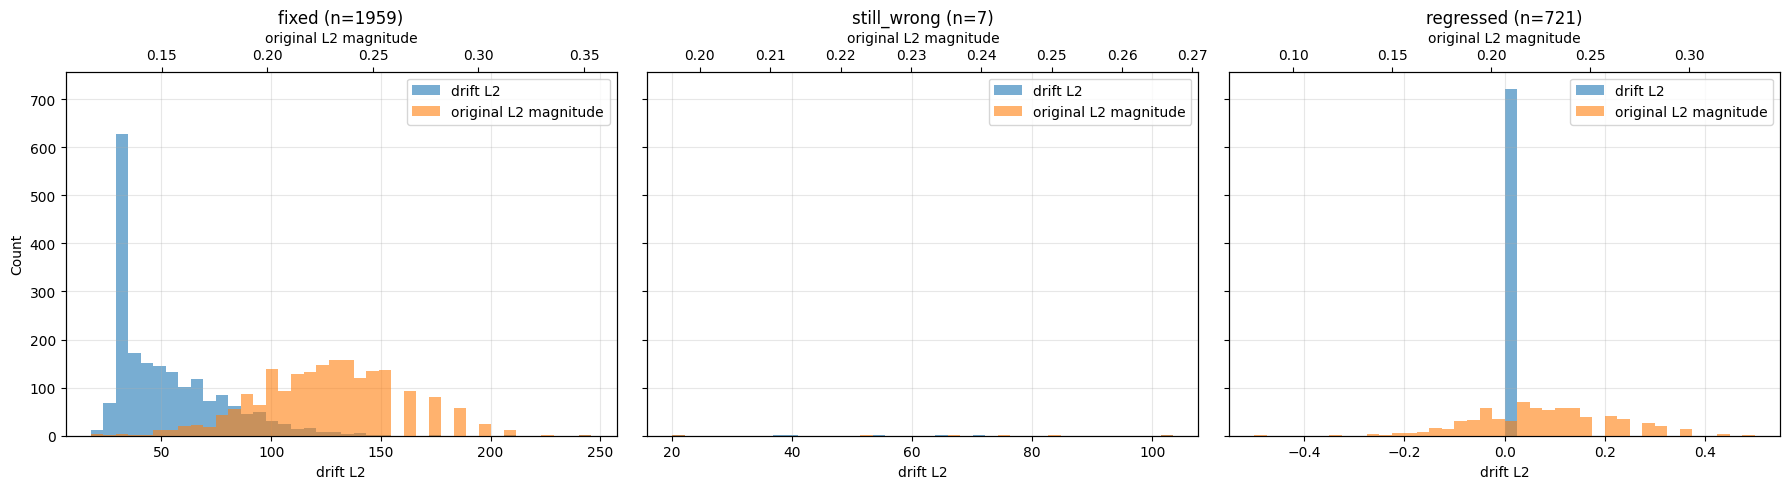

In [17]:
groups = [
    ("fixed", fixed_mask),
    ("still_wrong", still_wrong_mask),
    ("regressed", regressed_mask),
]

original_l2 = x_original.norm(dim=1).detach().cpu()
drift_l2_cpu = drift_l2.detach().cpu()

fig, axes_sep = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (name, mask) in zip(axes_sep, groups):
    mask_cpu = mask.detach().cpu()
    n = int(mask_cpu.sum().item())

    ax_top = ax.twiny()  # separate x-scale for original L2

    if n > 0:
        dvals = drift_l2_cpu[mask_cpu].numpy()
        ovals = original_l2[mask_cpu].numpy()

        ax.hist(dvals, bins=40, alpha=0.6, color="tab:blue", label="drift L2")
        ax_top.hist(ovals, bins=40, alpha=0.6, color="tab:orange", label="original L2 magnitude")

    ax.set_title(f"{name} (n={n})")
    ax.set_xlabel("drift L2")
    ax_top.set_xlabel("original L2 magnitude")
    ax.grid(alpha=0.3)

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax_top.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper right")

axes_sep[0].set_ylabel("Count")
plt.tight_layout()
plt.show()


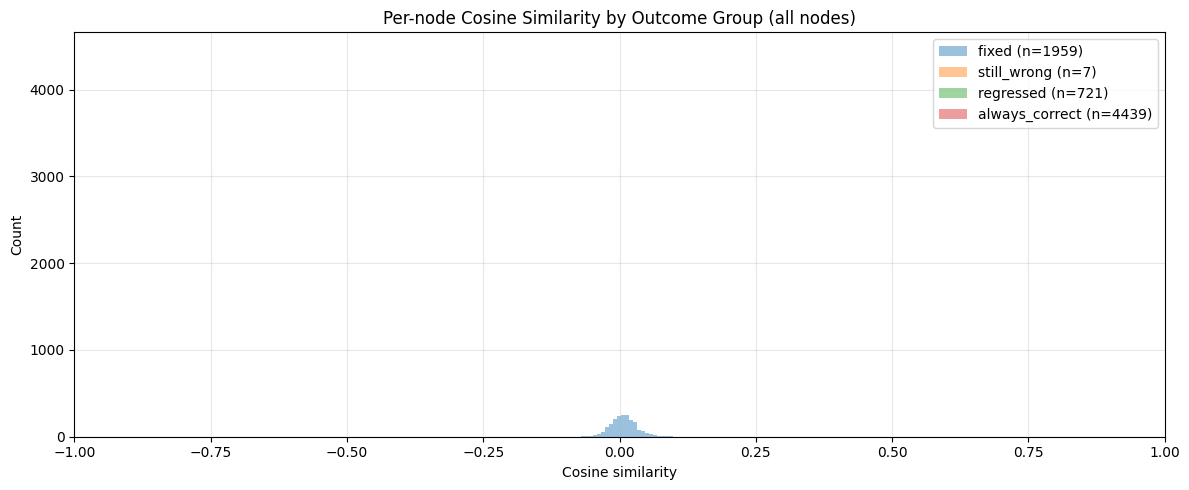

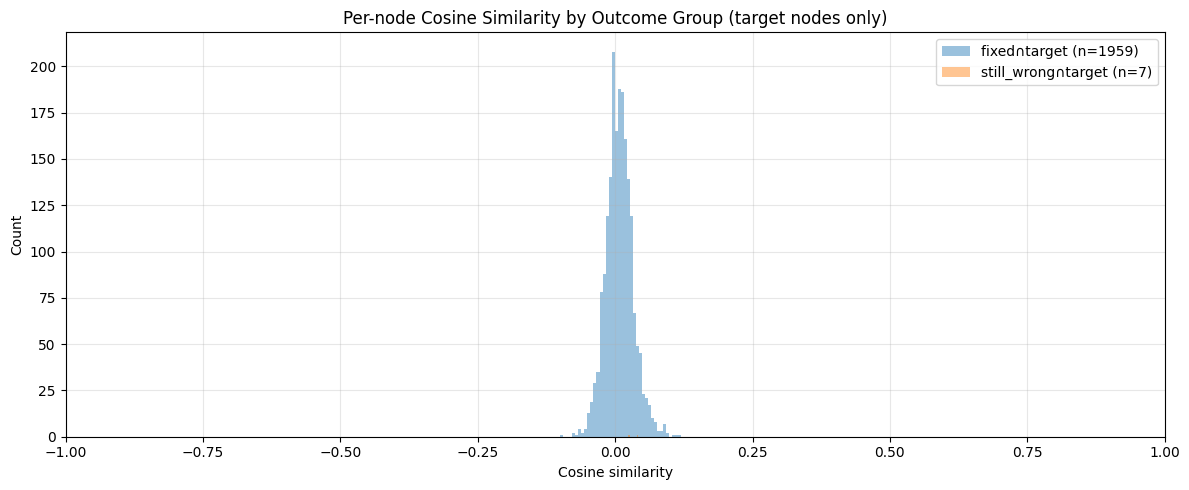

In [ ]:
# Cosine-similarity plots by outcome group (instead of L2 drift)

plot_groups_cos = [
    ("fixed", fixed_mask),
    ("still_wrong", still_wrong_mask),
    ("regressed", regressed_mask),
    ("always_correct", always_correct_mask),
]

cos_sim_cpu = cos_sim.detach().cpu()

# 1) All nodes by group
plt.figure(figsize=(12, 5))
for name, mask in plot_groups_cos:
    mask_cpu = mask.detach().cpu()
    if mask_cpu.sum() > 0:
        vals = cos_sim_cpu[mask_cpu].numpy()
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            continue

        vmin, vmax = vals.min(), vals.max()
        if np.isclose(vmin, vmax):
            # avoid zero-width / non-finite bin range
            plt.hist(vals, bins=np.linspace(vmin - 1e-6, vmax + 1e-6, 2),
                 alpha=0.45, label=f"{name} (n={int(mask_cpu.sum())})")
        else:
            plt.hist(vals, bins=30, range=(vmin, vmax),
                 alpha=0.45, label=f"{name} (n={int(mask_cpu.sum())})")
plt.title("Per-node Cosine Similarity by Outcome Group (all nodes)")
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.xlim(-1.0, 1.0)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 2) Target nodes only (more informative for moved nodes)
plt.figure(figsize=(12, 5))
for name, mask in plot_groups_cos:
    mask_t = (mask & target_mask).detach().cpu()
    if mask_t.sum() > 0:
        vals_t = cos_sim_cpu[mask_t].numpy()
        plt.hist(vals_t, bins=40, alpha=0.45, label=f"{name}∩target (n={int(mask_t.sum())})")
plt.title("Per-node Cosine Similarity by Outcome Group (target nodes only)")
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.xlim(-1.0, 1.0)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

KeyError: 'train'

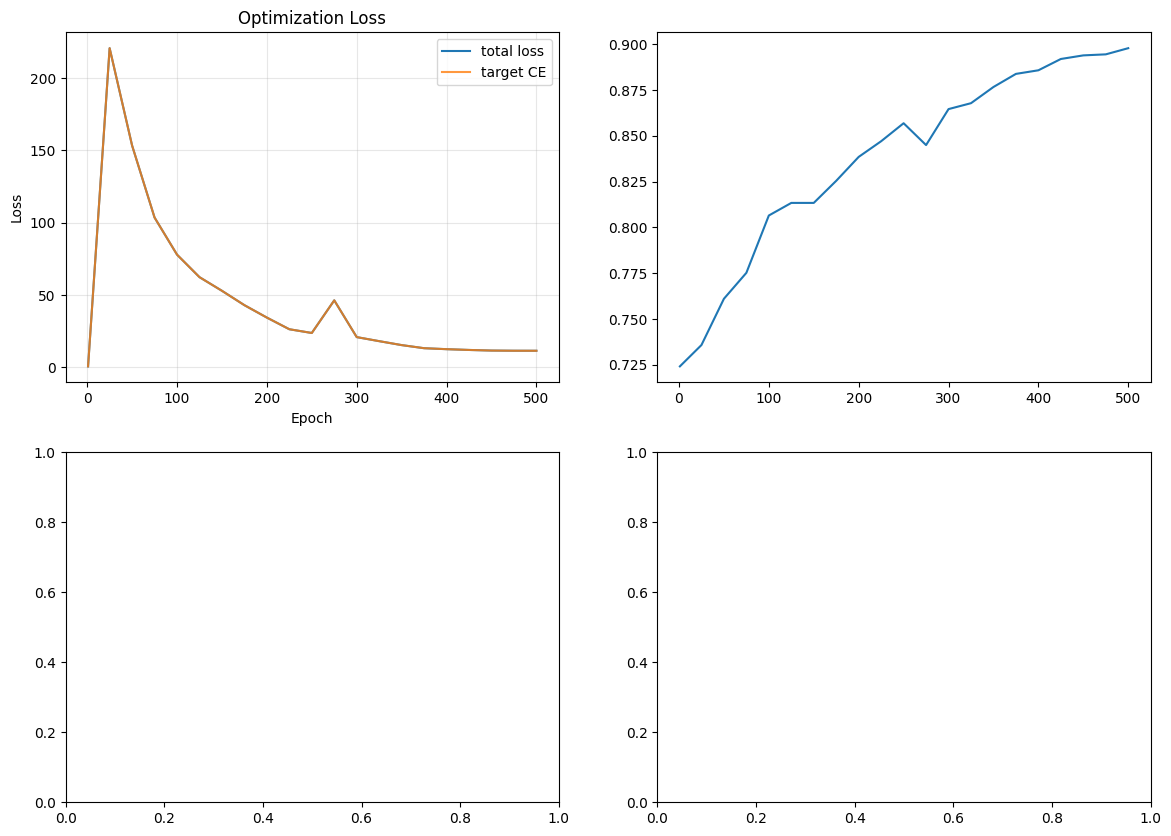

In [ ]:
""" # ---- Graphics ----
epochs = history['epoch']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) Loss trajectory
axes[0, 0].plot(epochs, history['loss_total'], label='total loss')
axes[0, 0].plot(epochs, history['loss_target_ce'], label='target CE', alpha=0.8)
axes[0, 0].set_title('Optimization Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

# (2) Accuracy trajectory
axes[0, 1].plot(epochs, history['overall'], label='overall')
axes[0, 1].plot(epochs, history['train'], label='train', alpha=0.8)
axes[0, 1].plot(epochs, history['val'], label='val', alpha=0.8)
axes[0, 1].plot(epochs, history['test'], label='test', alpha=0.8)
axes[0, 1].axhline(metrics_base['overall'], linestyle=':', color='k', alpha=0.6, label='baseline overall')
axes[0, 1].set_title('Accuracy Trajectory')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

# (3) Fixed / regressed / net
axes[1, 0].plot(epochs, history['fixed'], label='fixed')
axes[1, 0].plot(epochs, history['regressed'], label='regressed')
axes[1, 0].plot(epochs, history['net'], label='net')
axes[1, 0].set_title('Repair Outcomes Over Time')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Node Count')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

# (4) Gradient + movement diagnostics
axes[1, 1].plot(epochs, history['target_grad_mean'], label='target grad mean')
axes[1, 1].plot(epochs, history['target_delta_l2_mean'], label='target delta L2 mean')
axes[1, 1].set_title('Gradient and Drift Diagnostics')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Distribution plots for feature drift by outcome group
plot_groups = [
    ('fixed', fixed_mask),
    ('still_wrong', still_wrong_mask),
    ('regressed', regressed_mask),
]

plt.figure(figsize=(12, 5))
for name, mask in plot_groups:
    if mask.sum() > 0:
        plt.hist(drift_l2[mask].detach().cpu().numpy(), bins=40, alpha=0.45, label=f'{name} (n={int(mask.sum())})')
plt.title('Per-node L2 Drift by Outcome Group')
plt.xlabel('L2 drift')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for name, mask in plot_groups:
    if mask.sum() > 0:
        plt.hist(drift_cosine[mask].detach().cpu().numpy(), bins=40, alpha=0.45, label=f'{name} (n={int(mask.sum())})')
plt.title('Per-node Cosine Distance by Outcome Group')
plt.xlabel('Cosine distance')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Entropy vs drift scatter for target nodes
entropy_t = entropy[target_mask].detach().cpu().numpy()
drift_l2_t = drift_l2[target_mask].detach().cpu().numpy()
fixed_t = fixed_mask[target_mask].detach().cpu().numpy()

plt.figure(figsize=(8, 6))
plt.scatter(entropy_t[~fixed_t], drift_l2_t[~fixed_t], alpha=0.35, s=12, label='not fixed')
plt.scatter(entropy_t[fixed_t], drift_l2_t[fixed_t], alpha=0.55, s=14, label='fixed')
plt.title('Target Nodes: Baseline Entropy vs L2 Drift')
plt.xlabel('Baseline entropy')
plt.ylabel('L2 drift')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show() """

## Next Iteration Ideas

- Add entropy-bucketed budgets instead of all-incorrect training at once.
- Add a small L2-to-original penalty sweep to reduce regressions.
- Add a trust-region clip on per-node delta norms.
- Add subgraph visualization with node color by fixed/regressed and node size by drift.